# Original

In [ ]:
import numpy as np
import cvxpy as cp

def ev_charging_allocation_linear(valuations, budgets, supply, prices_0, learning_rate, num_iters, decay=True):
    prices = np.copy(prices_0)
    prices_hist = []
    demands_hist = []

    num_buyers, num_goods = valuations.shape

    print("========== Initial Input Information ==========")
    print("Valuations:")
    print(valuations)
    print("Budgets:")
    print(budgets)
    print("Supply:")
    print(supply)
    print("Initial Prices:")
    print(prices)
    print("Learning Rate:", learning_rate)
    print("Number of Iterations:", num_iters)
    print("===============================================\n")

    for iter_outer in range(1, num_iters):
        if (not iter_outer % 50):
            print(f" ----- Iteration {iter_outer}/{num_iters} ----- ")
        prices_hist.append(prices.copy())

        demands = np.zeros_like(valuations)

        X = cp.Variable(valuations.shape)
        obj = cp.Maximize(np.sum(prices) + budgets.T @ cp.log(cp.sum(cp.multiply(valuations, X), axis = 1)))
        constr = [X>=0, X @ prices <= budgets]
        prob = cp.Problem(obj, constr)
        try:
            prob.solve(solver="ECOS")
        except cp.SolverError:
            prob.solve(solver="SCS")


        demands = X.value

        demands = demands.clip(min = 0)
        demands_hist.append(demands)
        demand = np.sum(demands, axis = 0)
        excess_demand = demand - supply

        print(f"--- Iteration {iter_outer}/{num_iters} ---")
        print("Current Prices:", prices)
        print("Excess Demand:", excess_demand)

        if (decay) :
            step_size = (iter_outer**(-1/2))*excess_demand

            prices += step_size*(prices > 0)
        else:
            step_size = learning_rate*excess_demand
            prices += step_size*(prices > 0)

        prices = prices.clip(min=0.01)


    return (demands, prices, demands_hist, prices_hist)

def main():
    num_buyers = 4
    num_chargers = 2
    num_time_slots = 2
    num_goods = num_chargers * num_time_slots


    np.random.seed(2001)
    valuations = np.random.randint(1, 11, size=(num_buyers, num_goods))
    budgets = np.random.randint(5, 21, size=num_buyers)

    supply = np.ones(num_goods)

    prices_0 = np.full(num_goods, 1.0)

    learning_rate = 0.1
    num_iters = 30000

    demands, final_prices, demands_hist, prices_hist = ev_charging_allocation_linear(
        valuations, budgets, supply, prices_0, learning_rate, num_iters, decay=True)

    print("\n========== Final Results ==========")
    print("Final Equilibrium Prices per Charger-Time Slot:")
    print(final_prices)
    print("\nFinal Allocation (demand) per EV driver (rows) for each good (columns):")
    print(demands)

if __name__ == "__main__":
    main()



========== Initial Input Information ==========
Valuations:
[[ 1  5  7  1]
 [ 7  6  1  2]
 [ 1  5  8 10]
 [ 5  8  4  9]]
Budgets:
[14  6 11 18]
Supply:
[1. 1. 1. 1.]
Initial Prices:
[1. 1. 1. 1.]
Learning Rate: 0.1
Number of Iterations: 30000

--- Iteration 1/30000 ---
Current Prices: [1. 1. 1. 1.]
Excess Demand: [ 4.99961772 -0.9999735  12.99993166 28.00038366]
--- Iteration 2/30000 ---
Current Prices: [5.99961772e+00 1.00000000e-02 1.39999317e+01 2.90003837e+01]
Excess Demand: [-1.0000000e+00  3.6272559e+04 -1.0000000e+00 -1.0000000e+00]
--- Iteration 3/30000 ---
Current Prices: [5.29251094e+00 2.56485824e+04 1.32928249e+01 2.82932769e+01]
Excess Demand: [ 3.53472015 -1.          0.88071426 -1.        ]
--- Iteration 4/30000 ---
Current Prices: [7.33328257e+00 2.56480051e+04 1.38013055e+01 2.77159266e+01]
Excess Demand: [ 2.27275409 -1.          0.81142573 -1.        ]
--- Iteration 5/30000 ---
Current Prices: [8.46965961e+00 2.56475051e+04 1.42070184e+01 2.72159266e+01]
Excess Deman

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


--- Iteration 29/30000 ---
Current Prices: [1.24692828e+01 2.56410727e+04 1.77998434e+01 2.24558876e+01]
Excess Demand: [ 0.92471803 -1.          0.40451886 -0.99999999]
--- Iteration 30/30000 ---
Current Prices: [1.26409986e+01 2.56408870e+04 1.78749607e+01 2.22701923e+01]
Excess Demand: [-0.5253419  -1.         -0.21676749  0.30220187]
--- Iteration 31/30000 ---
Current Prices: [1.25450847e+01 2.56407044e+04 1.78353846e+01 2.23253666e+01]
Excess Demand: [-0.52172223 -0.99999999  0.40169529 -0.19375664]
--- Iteration 32/30000 ---
Current Prices: [1.24513807e+01 2.56405248e+04 1.79075312e+01 2.22905669e+01]
Excess Demand: [-0.51812158 -1.         -0.21821395  0.3009991 ]
--- Iteration 33/30000 ---
Current Prices: [1.23597888e+01 2.56403480e+04 1.78689560e+01 2.23437765e+01]
Excess Demand: [ 0.94176718 -0.99999999  0.39908361 -0.99999998]
--- Iteration 34/30000 ---
Current Prices: [1.25237295e+01 2.56401739e+04 1.79384276e+01 2.21696988e+01]
Excess Demand: [-0.52091481 -1.         -0.21

# With plot

----- Iteration 500/100000 -----
----- Iteration 1000/100000 -----
----- Iteration 1500/100000 -----
----- Iteration 2000/100000 -----
----- Iteration 2500/100000 -----
----- Iteration 3000/100000 -----
----- Iteration 3500/100000 -----
----- Iteration 4000/100000 -----
----- Iteration 4500/100000 -----
----- Iteration 5000/100000 -----
----- Iteration 5500/100000 -----
----- Iteration 6000/100000 -----
----- Iteration 6500/100000 -----
----- Iteration 7000/100000 -----
----- Iteration 7500/100000 -----
----- Iteration 8000/100000 -----
----- Iteration 8500/100000 -----
----- Iteration 9000/100000 -----
----- Iteration 9500/100000 -----
----- Iteration 10000/100000 -----
----- Iteration 10500/100000 -----
----- Iteration 11000/100000 -----
----- Iteration 11500/100000 -----
----- Iteration 12000/100000 -----
----- Iteration 12500/100000 -----
----- Iteration 13000/100000 -----
----- Iteration 13500/100000 -----
----- Iteration 14000/100000 -----
----- Iteration 14500/100000 -----
-----

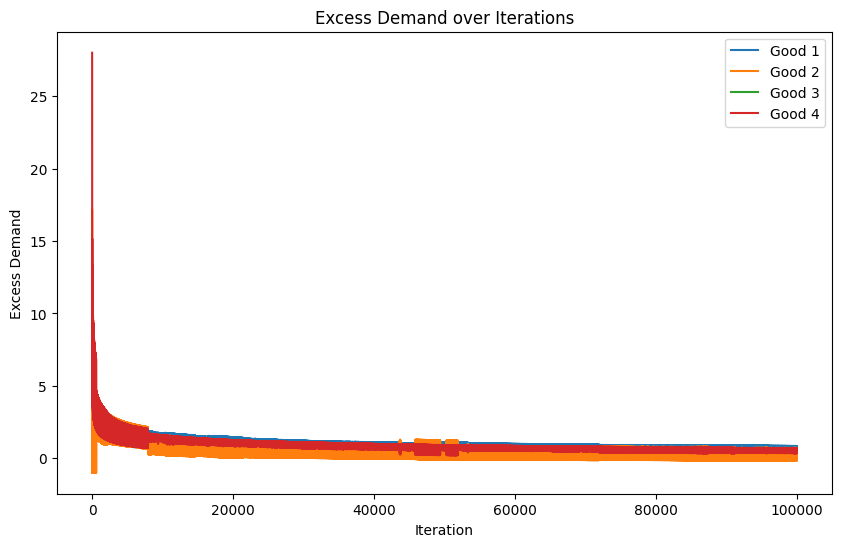

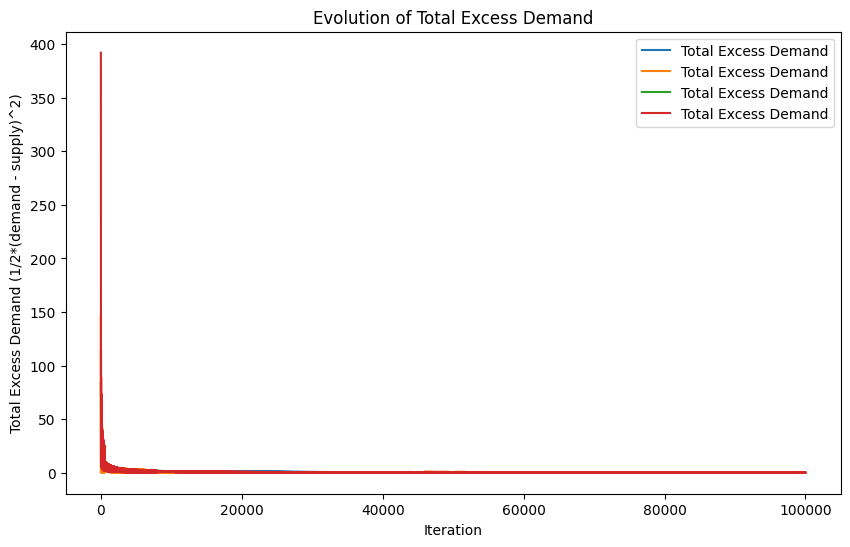

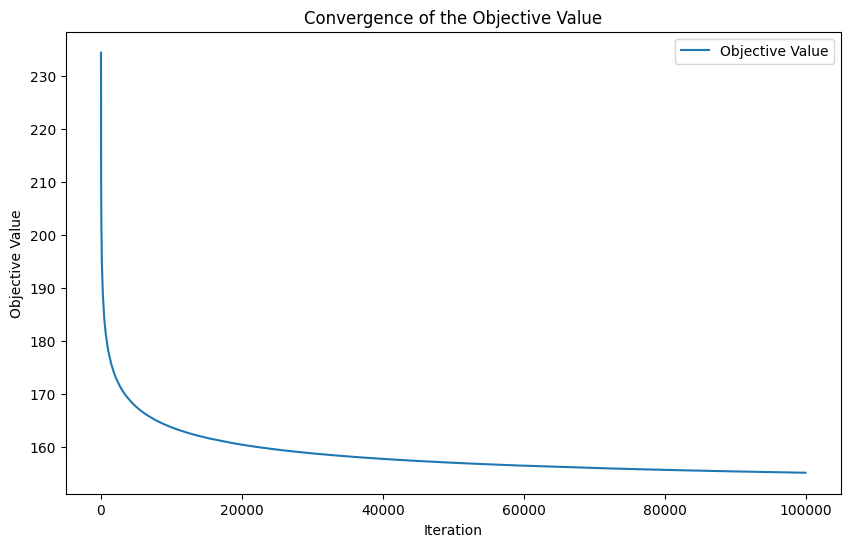

In [ ]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt

def ev_charging_allocation_linear(valuations, budgets, supply, prices_0, learning_rate, num_iters, decay=True):
    prices = np.copy(prices_0)
    prices_hist = []
    demands_hist = []
    excess_demand_hist = []
    total_excess_hist = []
    obj_hist = []
    num_buyers, num_goods = valuations.shape

    for iter_outer in range(1, num_iters):
        if iter_outer % 500 == 0:
            print(f"----- Iteration {iter_outer}/{num_iters} -----")

        prices_hist.append(prices.copy())

        X = cp.Variable(valuations.shape)
        obj = cp.Maximize(np.sum(prices) + budgets.T @ cp.log(cp.sum(cp.multiply(valuations, X), axis=1)))
        constr = [X >= 0, X @ prices <= budgets]
        prob = cp.Problem(obj, constr)
        try:
            prob.solve(solver="ECOS")
        except cp.SolverError:
            prob.solve(solver="SCS")

        demands = X.value.clip(min=0)
        demands_hist.append(demands)

        demand = np.sum(demands, axis=0)
        excess_demand = demand - supply
        excess_demand_hist.append(excess_demand.copy())

        # total_excess = 0.5 * np.sum((excess_demand)**2)
        total_excess = 0.5 * ((excess_demand)**2)

        total_excess_hist.append(total_excess)
        # print(f"----- Excess demand {excess_demand}/{total_excess} -----,  Obj = {obj:.4f}")
        if decay:
            step_size = (iter_outer**(-1/2)) * excess_demand
        else:
            step_size = (iter_outer**(-1/2)) * learning_rate * excess_demand

        prices += step_size * (prices > 0)
        prices = prices.clip(min=0.01)

        u = np.sum(valuations * demands, axis=1)
        curr_obj = np.sum(prices) + np.sum(budgets * np.log(u + 1e-12))
        obj_hist.append(curr_obj)
        # print(f"----- Excess demand {excess_demand}/{total_excess} -----,  Obj = {curr_obj:.4f}")

    return demands, prices, demands_hist, prices_hist, excess_demand_hist, total_excess_hist, obj_hist

def main():
    num_buyers = 4
    num_chargers = 2
    num_time_slots = 2
    num_goods = num_chargers * num_time_slots

    np.random.seed(2001)
    valuations = np.random.randint(1, 11, size=(num_buyers, num_goods))
    budgets = np.random.randint(5, 21, size=num_buyers)

    supply = np.ones(num_goods)
    prices_0 = np.full(num_goods, 1.0)

    learning_rate = 1e-2
    num_iters = 100000

    demands, final_prices, demands_hist, prices_hist, excess_demand_hist, total_excess_hist, obj_hist = ev_charging_allocation_linear(
        valuations, budgets, supply, prices_0, learning_rate, num_iters, decay=False)

    print("\n========== Final Results ==========")
    print("Final Equilibrium Prices per Charger-Time Slot:")
    print(final_prices)
    print("\nFinal Allocation (demand) per EV driver (rows) for each good (columns):")
    print(demands)
    print("\nFinal total excess demand:")
    print(total_excess_hist[-1])
    excess_demand_hist = np.array(excess_demand_hist)

#     plt.figure(figsize=(10, 6))
#     for good in range(excess_demand_hist.shape[1]):
#         plt.plot(excess_demand_hist[:, good], label=f"Good {good+1}")
#     plt.xlabel("Iteration")
#     plt.ylabel("Excess Demand")
#     plt.title("Excess Demand over Iterations")
#     plt.legend()
#     plt.show()s


    start_iter = 1
    excess_demand_subset = excess_demand_hist[start_iter - 1:, :]
    total_excess_hist_subset = total_excess_hist[start_iter - 1:]
    iterations = np.arange(start_iter, num_iters)

    plt.figure(figsize=(10, 6))
    for good in range(excess_demand_subset.shape[1]):
        plt.plot(iterations, excess_demand_subset[:, good], label=f"Good {good+1}")

    plt.xlabel("Iteration")
    plt.ylabel("Excess Demand")
    plt.title("Excess Demand over Iterations")
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.plot(iterations, total_excess_hist_subset, label="Total Excess Demand")
    plt.xlabel("Iteration")
    plt.ylabel("Total Excess Demand (1/2*(demand - supply)^2)")
    plt.title("Evolution of Total Excess Demand")
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.plot(iterations, obj_hist, label="Objective Value")
    plt.xlabel("Iteration")
    plt.ylabel("Objective Value")
    plt.title("Convergence of the Objective Value")
    plt.legend()
    plt.show()

if __name__ == "__main__":
    main()
